### 对于MLP隐藏层权重的可视化

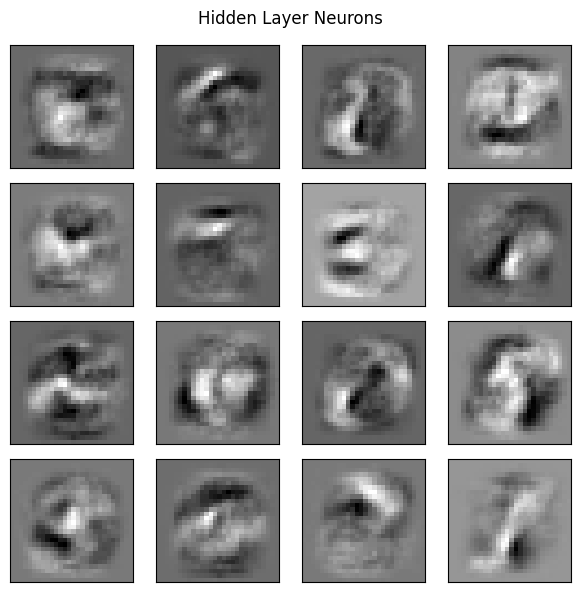

In [1]:
import mynn
import numpy as np
from struct import unpack
import gzip
import matplotlib.pyplot as plt
import pickle

# 加载模型
model = mynn.models.Model_MLP()
model.load_model(r'.\saved_models\Q1\hidden_128_He\best_model.pickle')

# 读取测试图像与标签
test_images_path = r'.\dataset\MNIST\t10k-images-idx3-ubyte.gz'
test_labels_path = r'.\dataset\MNIST\t10k-labels-idx1-ubyte.gz'

with gzip.open(test_images_path, 'rb') as f:
    magic, num, rows, cols = unpack('>4I', f.read(16))
    test_imgs = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(test_labels_path, 'rb') as f:
    magic, num = unpack('>2I', f.read(8))
    test_labs = np.frombuffer(f.read(), dtype=np.uint8)

test_imgs = test_imgs / 255.0

# 提取模型的权重
W1 = model.layers[0].params['W']  # shape: [input_dim, hidden_dim]
W2 = model.layers[2].params['W']  # shape: [hidden_dim, output_dim]

# 可视化第一个隐藏层的神经元权重
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
axes = axes.reshape(-1)
for i in range(16):
    axes[i].imshow(W1[:, i].reshape(28, 28), cmap='gray')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
fig.suptitle("Hidden Layer Neurons")
plt.tight_layout()
plt.show()




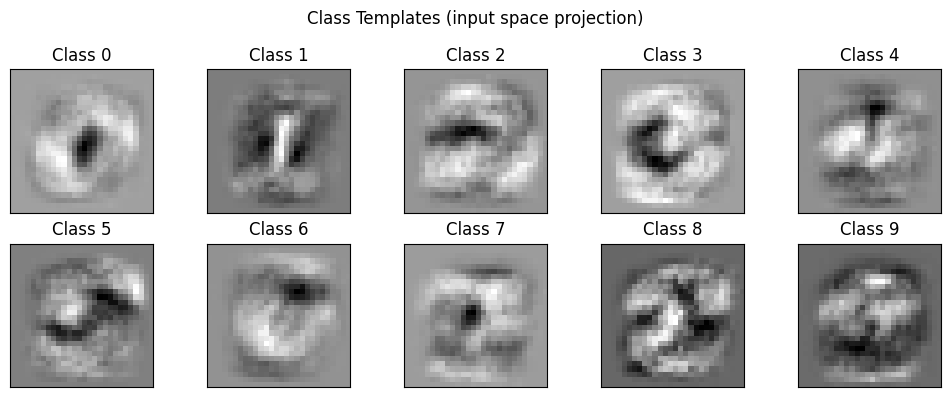

In [2]:
# 计算每个类别输出神经元对输入的“反向影响”
# 即 template_c = W1 @ W2[:, c]
templates = W1 @ W2  # shape: [input_dim, output_dim]

# 可视化每个类别的模板
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.reshape(-1)
for i in range(10):
    axes[i].imshow(templates[:, i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Class {i}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])
fig.suptitle("Class Templates (input space projection)")
plt.tight_layout()
plt.show()

### CNN的可视化

In [3]:
conv_configs = [   
    {
        'layer_type': 'conv',
        'in_channels': 1,
        'out_channels': 8,     # 减小通道数
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    },
    {
        'layer_type': 'conv',
        'in_channels': 8,
        'out_channels': 16,
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    }
]

fc_configs = [
    {"in_dim": 784, "out_dim": 10, "weight_decay": True, "weight_decay_lambda": 1e-4},
]

model = mynn.models.Model_CNN(
    conv_layer_config = conv_configs,
    fully_connected_config = fc_configs,
    activation_function = 'ReLU',
    apply_global_avg_pool = False
)

# 加载模型
model.load_model(r'.\saved_models\Q5\cnn_model2\best_model.pickle')

W mean, std = 0.1398, 0.3421
Conv Layer 0: 原始卷积核 shape = (8, 1, 3, 3)


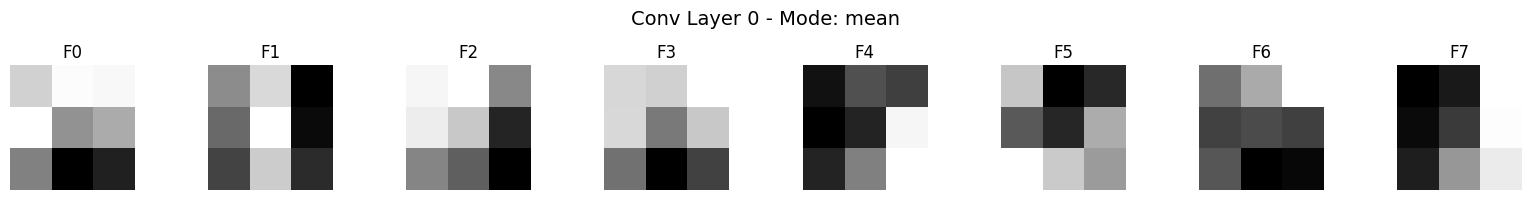

W mean, std = 0.0053, 0.0967
Conv Layer 1: 原始卷积核 shape = (16, 8, 3, 3)


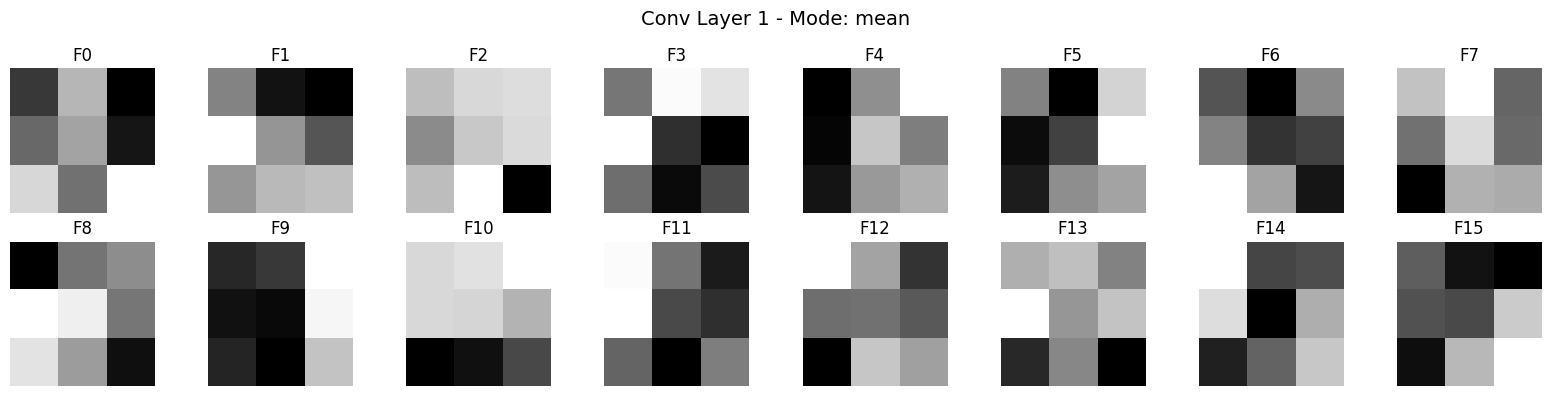

W mean, std = 0.0001, 0.0386


In [11]:
def normalize_filter(f):
    """
    将单个滤波器归一化到 0~1 之间
    """
    f_min, f_max = f.min(), f.max()
    if f_max - f_min > 1e-8:
        return (f - f_min) / (f_max - f_min)
    else:
        return np.zeros_like(f)

def visualize_conv_kernels(model_path, mode='mean', max_filters=64):
    """
    可视化 CNN 模型中每个卷积层的卷积核（带归一化）

    参数:
        model_path (str): 模型文件路径 (.pickle)
        mode (str): 可视化模式，可选 'mean' 或 'all'
        max_filters (int): 每层最多显示多少个卷积核
    """
    model = mynn.models.Model_CNN()
    model.load_model(model_path)

    conv_layer_idx = 0
    for idx, layer in enumerate(model.layers):
        if hasattr(layer, 'params') and 'W' in layer.params:
            W = layer.params['W']  # shape: [out_c, in_c, kH, kW]
            print(f"W mean, std = {W.mean():.4f}, {W.std():.4f}")
            if W.ndim != 4:
                continue  # 跳过非 conv 层

            print(f"Conv Layer {conv_layer_idx}: 原始卷积核 shape = {W.shape}")

            # 模式处理
            if mode == 'mean':
                filters = np.mean(W, axis=1)  # shape: [out_c, kH, kW]
            elif mode == 'all':
                filters = W.reshape(-1, *W.shape[2:])  # shape: [out_c * in_c, kH, kW]
            else:
                raise ValueError("mode needs 'mean' or 'all'")

            num_filters = min(len(filters), max_filters)
            ncols = 8 if num_filters >= 8 else num_filters
            nrows = int(np.ceil(num_filters / ncols))

            fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2, nrows * 2))
            axes = axes.flatten()

            for i in range(num_filters):
                filt = normalize_filter(filters[i])  # 🔹加入归一化
                axes[i].imshow(filt, cmap='gray')
                axes[i].axis('off')
                axes[i].set_title(f'F{i}')
            for i in range(num_filters, len(axes)):
                axes[i].axis('off')

            fig.suptitle(f"Conv Layer {conv_layer_idx} - Mode: {mode}", fontsize=14)
            plt.tight_layout()
            plt.show()

            conv_layer_idx += 1

visualize_conv_kernels(r'.\saved_models\Q5\cnn_model2\best_model.pickle')

#### 特征图

In [5]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()

# 在现有预处理基础上增加维度扩展
train_imgs = train_imgs.reshape(-1, 1, 28, 28)  # 转换为[N, C, H, W]格式
valid_imgs = valid_imgs.reshape(-1, 1, 28, 28)

In [6]:
def visualize_feature_maps(model, input_image, max_maps=16):
    """
    可视化模型每层的特征图，包括卷积层和池化层。

    Args:
        model: 加载好的 CNN 模型
        input_image: 单张输入图像，shape: [1, 1, 28, 28]
        max_maps: 每层最多显示多少个通道的特征图
    """
    x = input_image
    layer_idx = 0

    for layer in model.layers:
        # 只处理卷积层和池化层
        if isinstance(layer, (mynn.op.conv2D, mynn.op.Pooling)):  # 如果是卷积层或池化层
            # 前向传播
            x = layer(x)

            # 获取该层的特征图
            feature_maps = x[0]  # [C, H, W]
            num_maps = min(feature_maps.shape[0], max_maps)
            ncols = 4
            nrows = int(np.ceil(num_maps / ncols))

            fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2, nrows * 2))
            axes = axes.flatten()

            for i in range(num_maps):
                fmap = feature_maps[i]
                
                # 确保 fmap 是二维数组
                if fmap.ndim != 2:
                    print(f"Feature map at layer {layer_idx}, map {i} is not 2D, shape: {fmap.shape}")
                    continue  # 跳过这个无效特征图

                # 归一化
                fmap = np.squeeze(fmap)  # 确保为 [H, W] 形状
                fmap -= np.min(fmap)
                fmap /= (np.max(fmap) + 1e-8)
                # 根据层类型选择 colormap
                cmap = 'gray' if isinstance(layer, mynn.op.conv2D) else 'viridis'
                axes[i].imshow(fmap, cmap=cmap)

                axes[i].axis('off')
                axes[i].set_title(f'F{i}')

            # 关闭多余的子图
            for i in range(num_maps, len(axes)):
                axes[i].axis('off')

            if isinstance(layer, mynn.op.conv2D):
                fig.suptitle(f"Layer {layer_idx}: Convolutional Feature Maps", fontsize=14)
            elif isinstance(layer, mynn.op.Pooling):
                fig.suptitle(f"Layer {layer_idx}: Pooling Feature Maps", fontsize=14)

            plt.tight_layout()
            plt.show()

        layer_idx += 1

In [7]:
def get_image_by_label(images, labels, target_label, index=0):
    """
    从数据集中获取指定标签的图像

    Args:
        images: 图像数据，形状 [N, 1, 28, 28]
        labels: 标签数据，形状 [N]
        target_label: 要找的标签(如3)
        index: 该标签下第几个图像（默认取第一个）

    Returns:
        指定标签的图像，形状 [1, 1, 28, 28]
    """
    matching_indices = np.where(labels == target_label)[0]
    if len(matching_indices) == 0:
        raise ValueError(f"找不到标签为 {target_label} 的图像")
    if index >= len(matching_indices):
        raise IndexError(f"标签 {target_label} 只有 {len(matching_indices)} 张图,index={index} 超出范围")
    return images[matching_indices[index:index+1]]


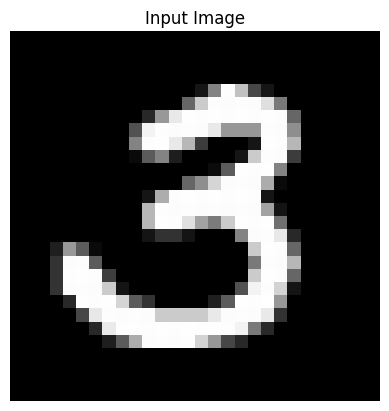

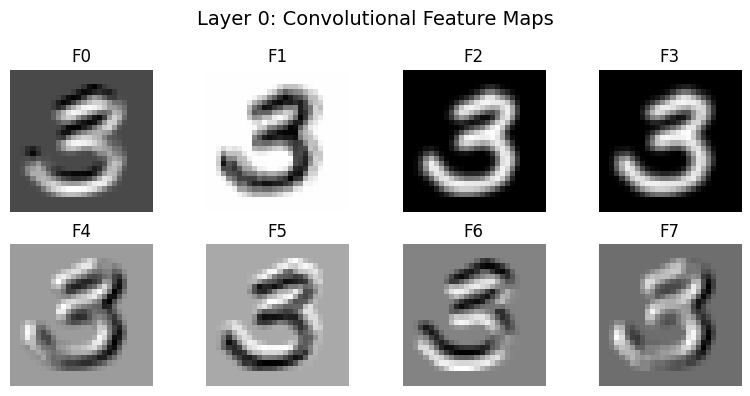

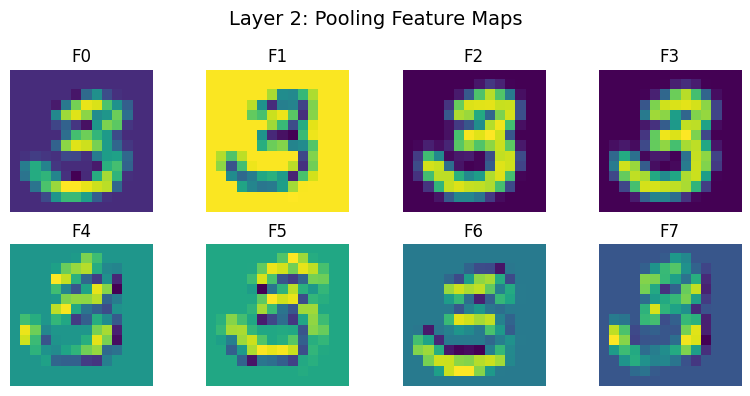

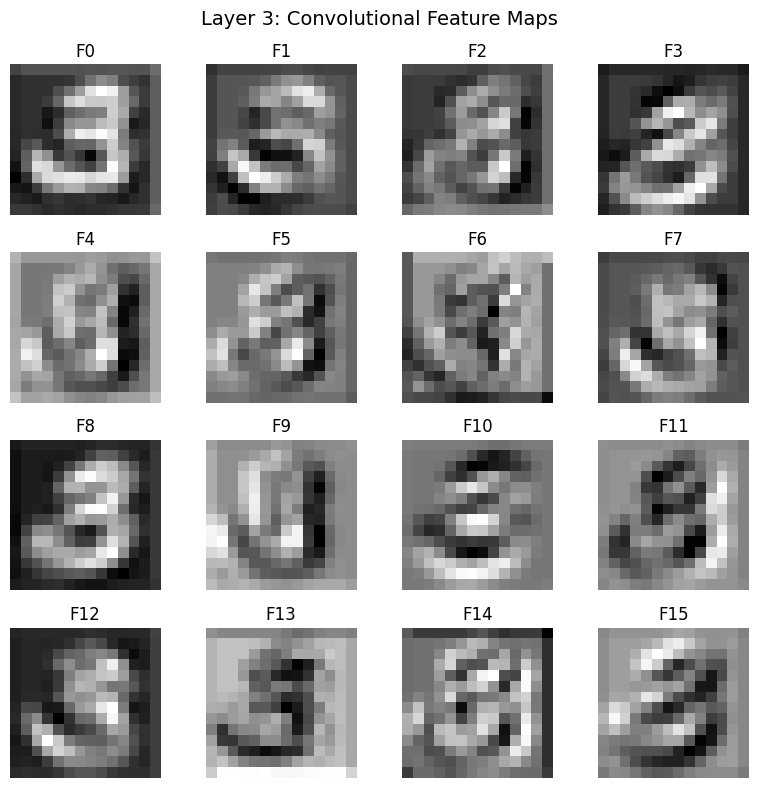

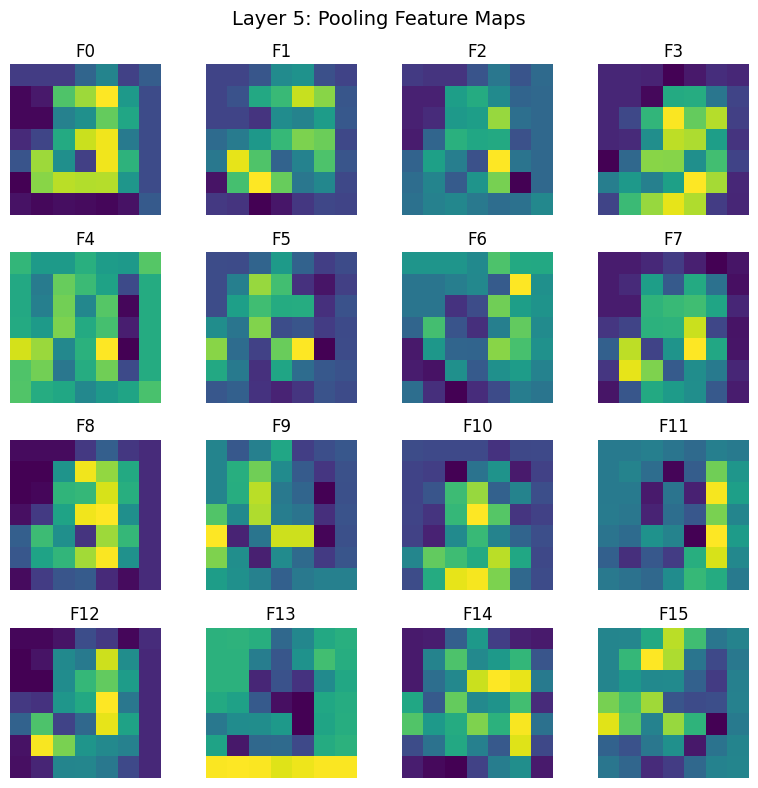

In [8]:
# 加载模型
model = mynn.models.Model_CNN()
model.load_model(r'.\saved_models\Q5\cnn_model2\best_model.pickle')

# 选择标签为 3 的图像（第 0 张）
img = get_image_by_label(valid_imgs, valid_labs, target_label=3, index=0)

# 可视化输入图像
plt.imshow(img[0][0], cmap='gray')
plt.axis('off')
plt.title("Input Image")
plt.show()

# 运行特征图可视化
visualize_feature_maps(model, img)


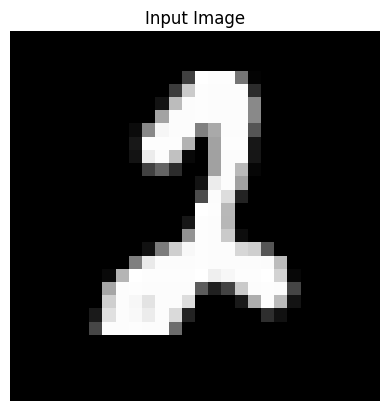

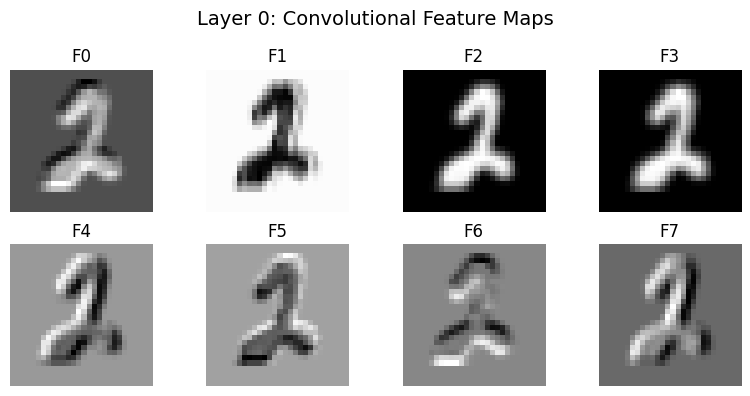

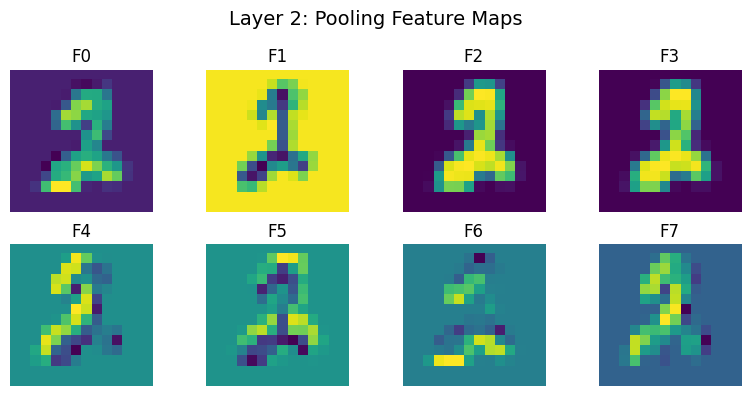

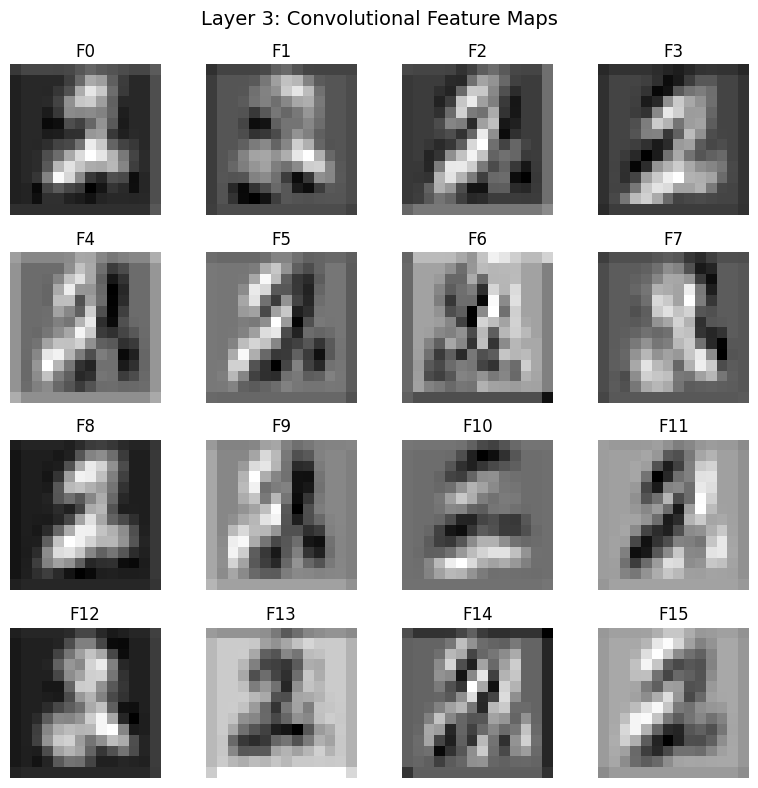

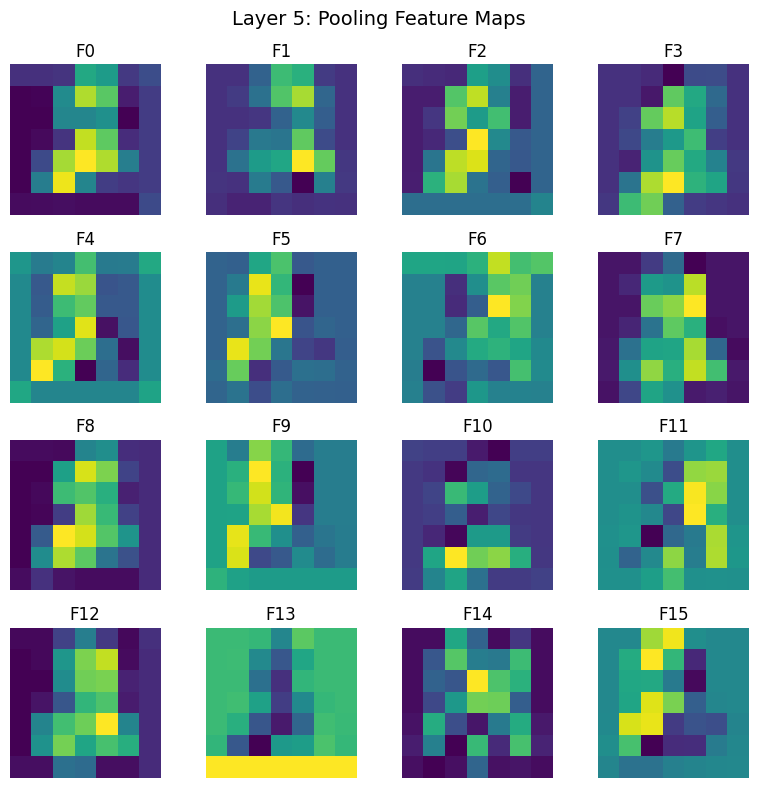

In [9]:
# 选择标签为 2 的图像（第 0 张）
img = get_image_by_label(valid_imgs, valid_labs, target_label=2, index=0)

# 可视化输入图像
plt.imshow(img[0][0], cmap='gray')
plt.axis('off')
plt.title("Input Image")
plt.show()

# 运行特征图可视化
visualize_feature_maps(model, img)

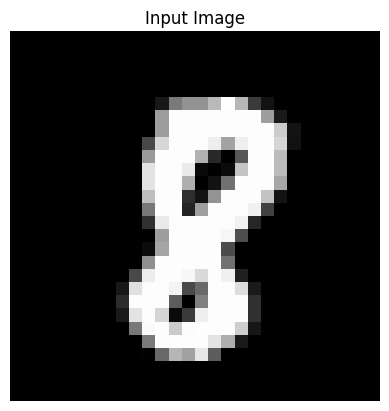

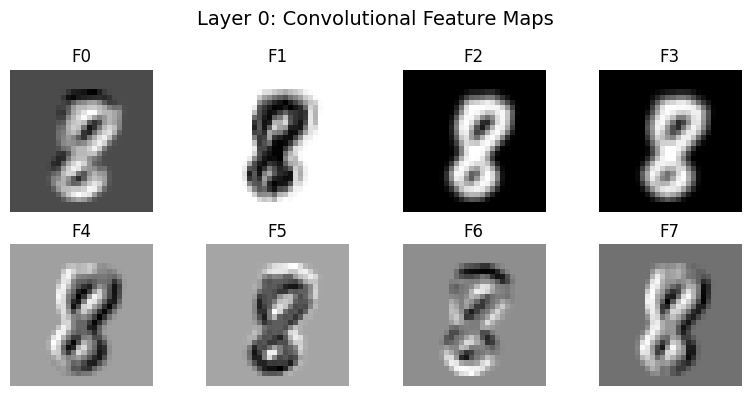

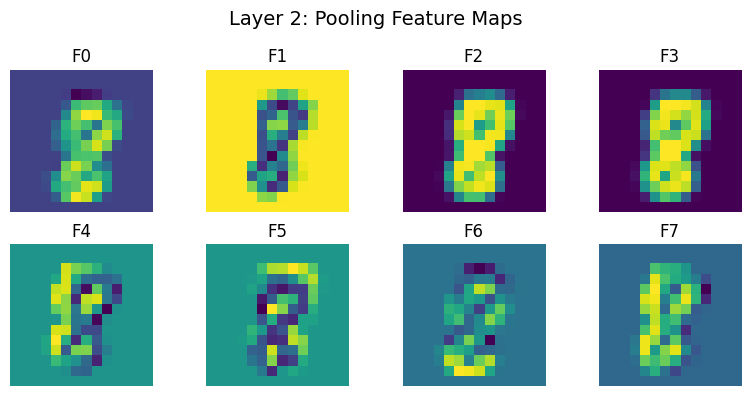

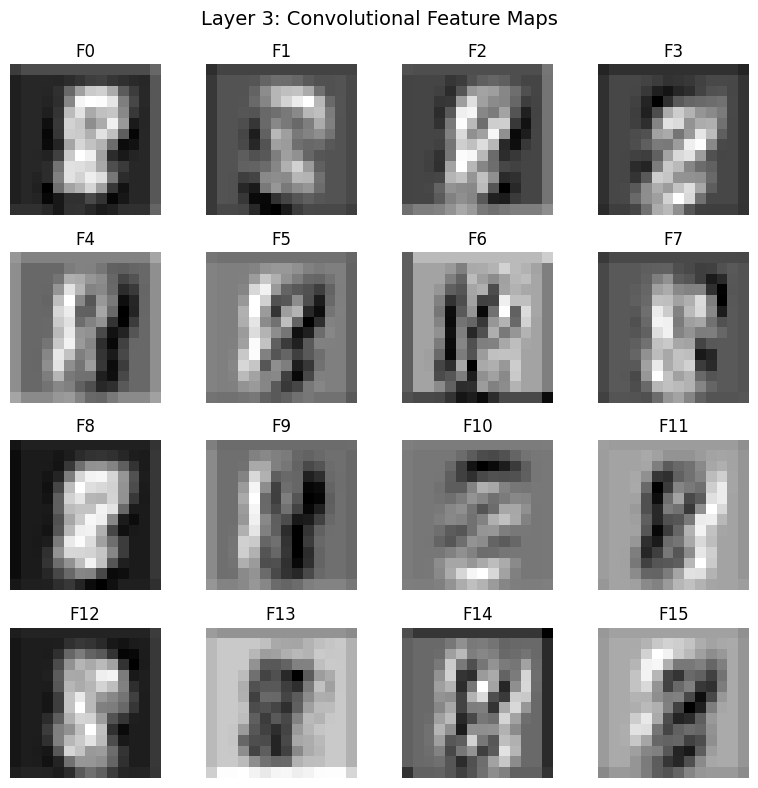

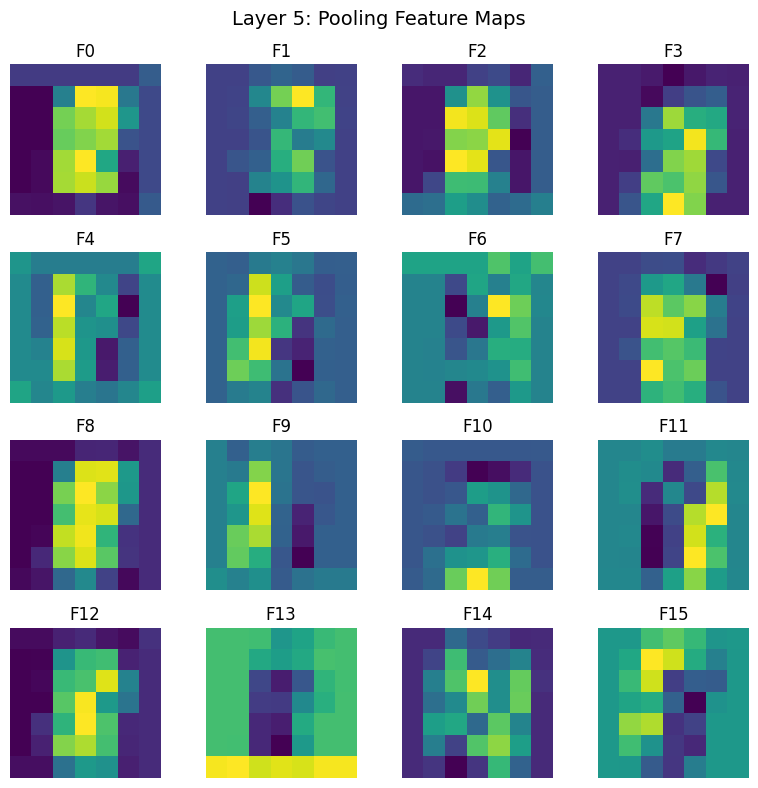

In [10]:
# 选择标签为 8 的图像（第 0 张）
img = get_image_by_label(valid_imgs, valid_labs, target_label= 8, index=0)

# 可视化输入图像
plt.imshow(img[0][0], cmap='gray')
plt.axis('off')
plt.title("Input Image")
plt.show()

# 运行特征图可视化
visualize_feature_maps(model, img)